In [ ]:
%pip install -q pandas numpy matplotlib scipy pyyaml

# Downstream Evaluation: RankMe Evolution → Multilingual Performance

**Research question:** *Does the shape of the RankMe trajectory during pre-training predict downstream multilingual performance? Specifically: does the point where compression begins (onset) and how long it lasts (duration) correlate with accuracy on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)  
**Geometry source:** (`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`)

### What this notebook does
1. **Phase identification** — detects two training phases from the RankMe curve: an *entropy-seeking* phase (RankMe ↑, the model builds richer representations) and a *compression-seeking* phase (RankMe ↓, the model specialises and compresses). For each phase, **onset** is the token count (in billions) where the phase begins, and **duration** is how long it lasts.
2. **Grokking detection** — finds the first checkpoint where accuracy rises more than 15 percentage points above random-chance and stays there for at least 2 consecutive checkpoints. Requires downstream eval results.
3. **Correlation analysis** — Spearman + Pearson tests: *does an earlier or longer compression phase predict earlier or higher accuracy?* Computed separately per task (m-MMLU / XCOPA), never pooled across tasks.
4. **Plots** — RankMe trajectories, phase overlays, dual-axis accuracy curves, and correlation scatter plots; all per-model plots include the model name in the filename.

> **Note:** Cells that require downstream evaluation results degrade gracefully if `results/eval/` is empty. Run `evaluate.py` (or `submit_eval.sh`) first, then rerun this notebook.

In [1]:
import warnings

import pandas as pd

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_geometry,
    compute_grokking,
    compute_correlations_table,
    plot_rankme_phases, plot_overlay,
    plot_predictor_scatter,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `load_config()` derives all paths, layer settings, grokking parameters, and benchmark metadata from `configs/benchmarks.yaml`.

Per-model plots (trajectories, phase overlays) are saved with the model name in the filename (e.g. `rankme_phases_fuxi.png`, `overlay_m_mmlu_apertus.png`). Combined scatter plots overlay both models in a single file.

In [2]:
MODELS = ["fuxi", "apertus"]

# Per-model colors and markers used in combined scatter plots.
_PALETTE = {
    "fuxi":    {"color": "steelblue",  "marker": "o"},
    "apertus": {"color": "darkorange", "marker": "s"},
}

data = {}
for m in MODELS:
    cfg = load_config(m)
    data[m] = {
        "cfg":    cfg,
        "color":  _PALETTE[m]["color"],
        "marker": _PALETTE[m]["marker"],
    }
    print(f"[{m}] {cfg['model_label']}  |  Layer: {cfg['layer']}  |  Aggregation: {cfg['aggregation']}")

[fuxi] FuxiTranyu-8B  |  Layer: layer_29  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_31  |  Aggregation: last


## Data

Two separate sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — RankMe geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for phase identification and phase plots. The working slice (`layer_29`, `agg=last`) gives one RankMe value per (checkpoint, language) pair across the full training run.

- **`fuxi_fine_wiki_merged.csv` / `apertus_fine_wiki_merged.csv`** — downstream accuracy merged with geometry metrics, produced by `merge_results.py` after running evaluation on the cluster. Used for grokking detection, correlation analysis, and overlay plots.

In [3]:
for m in MODELS:
    cfg = data[m]["cfg"]
    df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(
        cfg["rankme_csv"], cfg["layer"], cfg["aggregation"])
    df_eval, eval_available = load_eval_data(cfg["merged_csv"])
    data[m].update({
        "df_rankme":       df_rankme,
        "df_layer":        df_layer,
        "checkpoints_all": checkpoints_all,
        "token_counts":    token_counts,
        "langs_sorted":    langs_sorted,
        "df_eval":         df_eval,
        "eval_available":  eval_available,
    })
    print()

Loaded RankMe: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_29, agg=last → 798 rows
Loaded eval: 741 records — 2 task(s), 57 checkpoint(s)

Loaded RankMe: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_31, agg=last → 616 rows
Loaded eval: 572 records — 2 task(s), 44 checkpoint(s)



## RankMe Trajectories

The table below summarises key geometry metrics per language, derived from the RankMe trajectory at the working layer:

- **peak (B)** — token count at the global RankMe maximum. For most languages in both models this is at or before the first observed checkpoint, meaning the peak occurred early in pre-training.
- **RankMe first ckpt** — representational richness at the first observed checkpoint; varies up to 10× across languages and is the strongest predictor of downstream accuracy for Apertus.
- **RankMe valley / valley (B)** — bottom of the initial compression descent, detected with K=2 robustness (two consecutive higher values required). All languages in both models share this initial descent.
- **Initial drop rate (1/B)** — (RankMe[first] − RankMe[valley]) / (valley_tokens − first_tokens); how steeply each language's representations compress during the initial descent.
- **RankMe last ckpt** — representational richness at the end of training.

In [4]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    df_geometry = compute_geometry(d["df_layer"], d["checkpoints_all"], d["token_counts"])
    d["df_geometry"] = df_geometry

    display_cols = {
        "language":                 "language",
        "peak_tokens":              "peak (B)",
        "rankme_first":             "RankMe first ckpt",
        "rankme_valley":            "RankMe valley",
        "valley_tokens":            "valley (B)",
        "rankme_initial_drop_rate": "initial drop rate (1/B)",
        "rankme_last":              "RankMe last ckpt",
    }
    print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
    print(df_geometry[list(display_cols)].rename(columns=display_cols).to_string(index=False))


── FuxiTranyu-8B ────────────────────────────────────────
  language  peak (B)  RankMe first ckpt  RankMe valley  valley (B)  initial drop rate (1/B)  RankMe last ckpt
    Arabic      10.0           117.9297        26.8548       126.0                 0.785128           77.6066
   Chinese      10.0           302.4599       125.3404       105.0                 1.864416          157.0904
   English      10.0           268.1290        75.0640       105.0                 2.032263          125.4628
   Finnish      10.0           123.1964        21.4725       105.0                 1.070778           69.6830
    French      10.0           223.1791        59.6941       105.0                 1.720895          126.6601
    German      10.0           294.7635        85.4854       105.0                 2.202927          171.1404
     Hindi      10.0           112.0574        18.6262       126.0                 0.805441           68.7412
Indonesian      10.0            80.5897        23.9355       

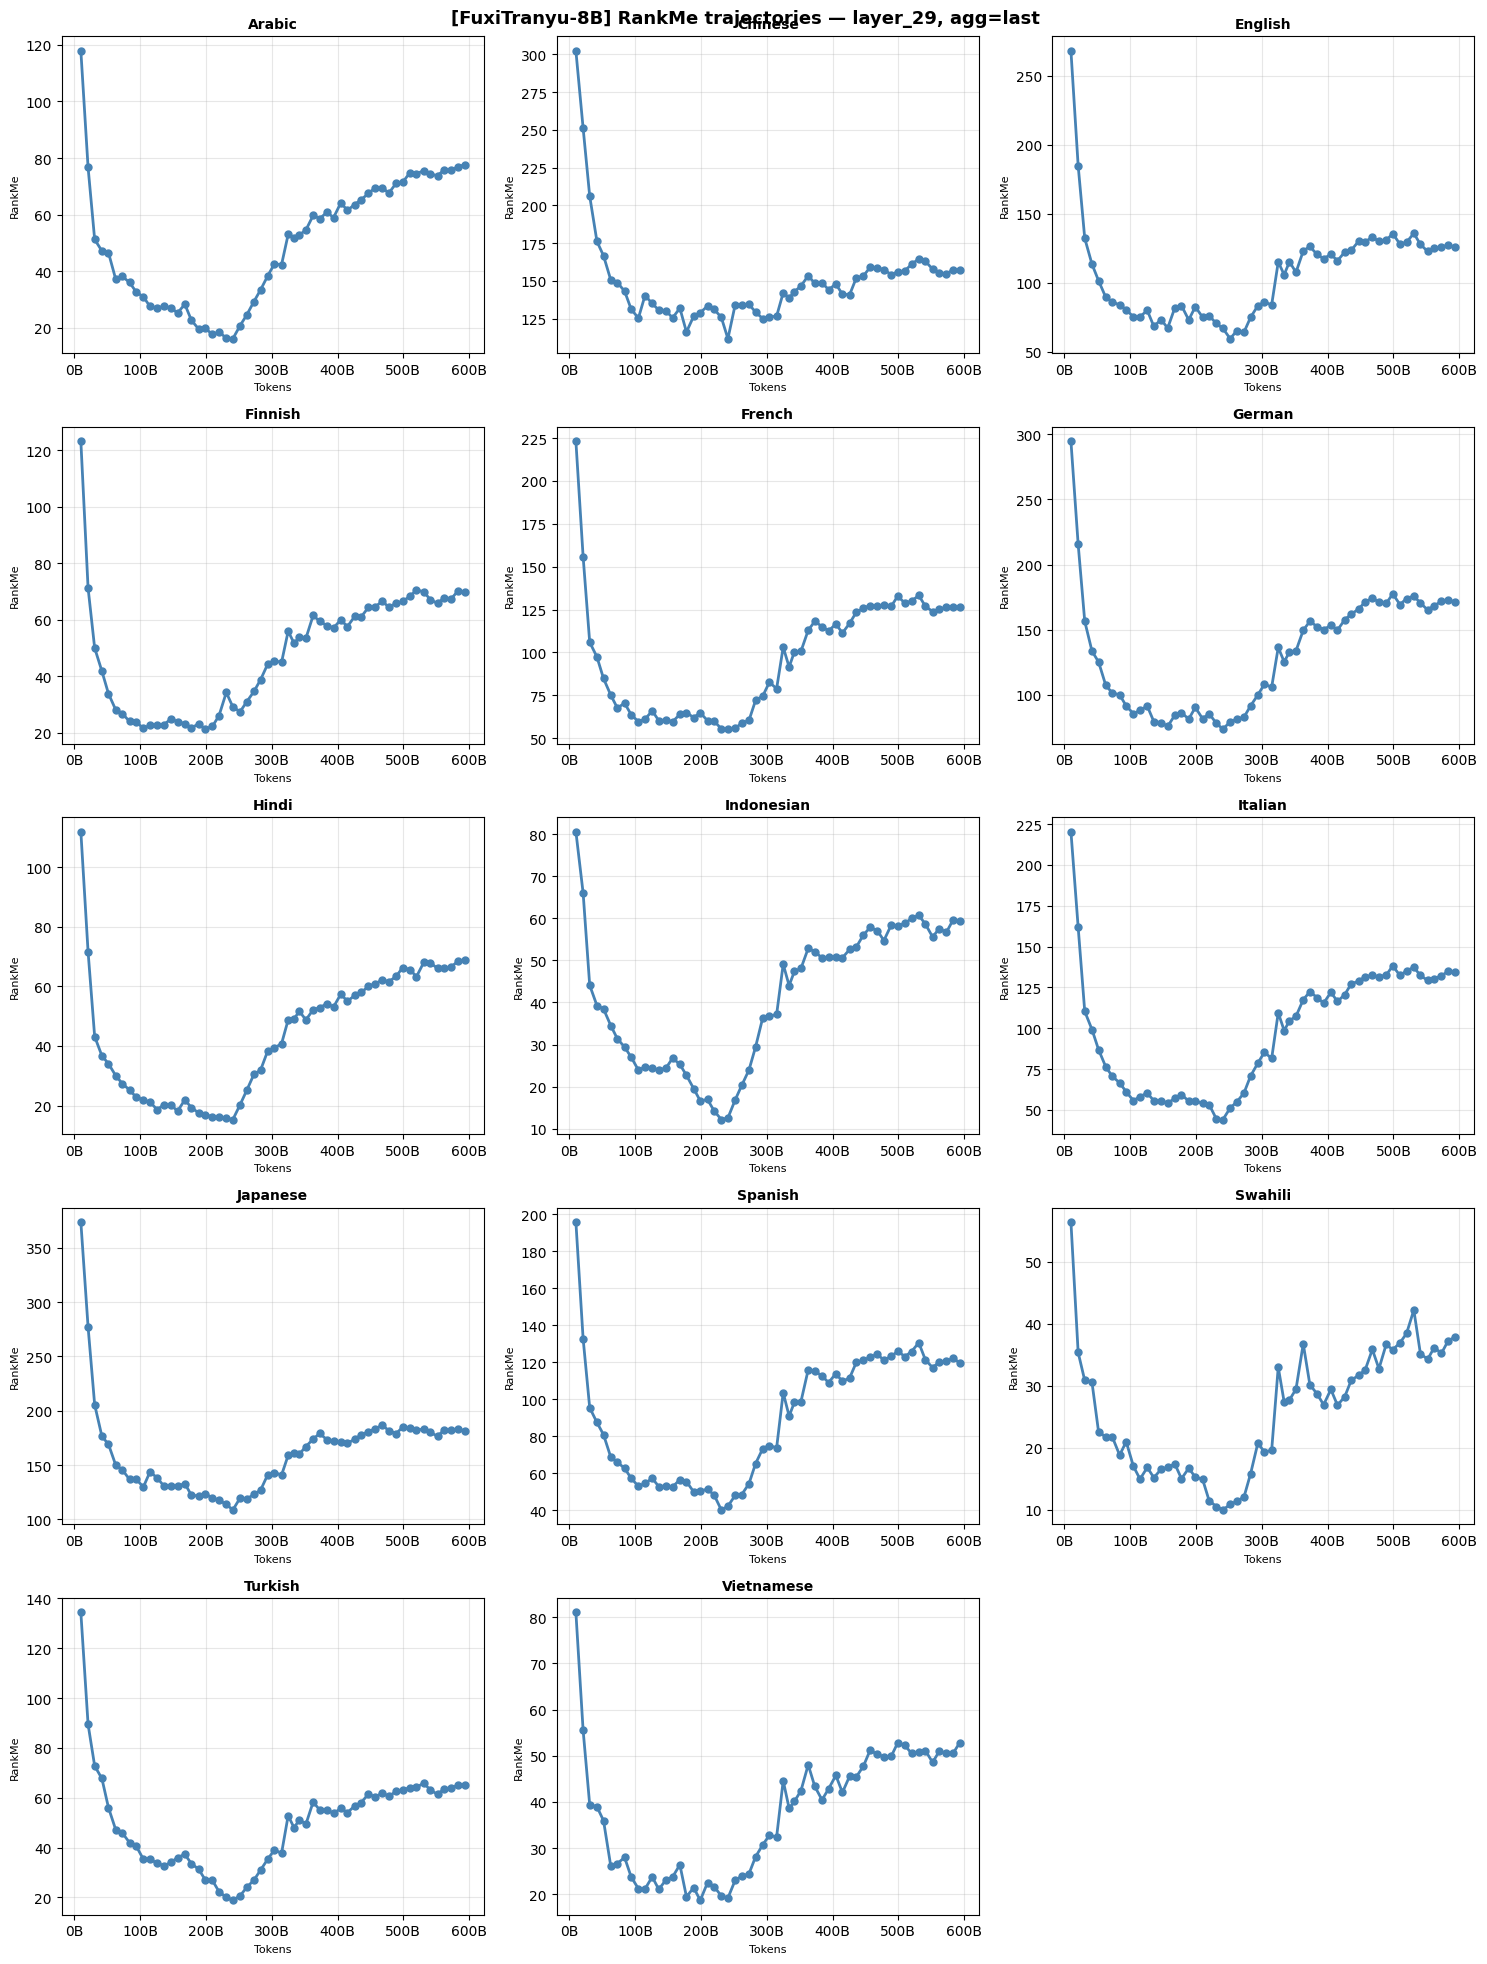

Saved: plots/rankme_phases_fuxi.png


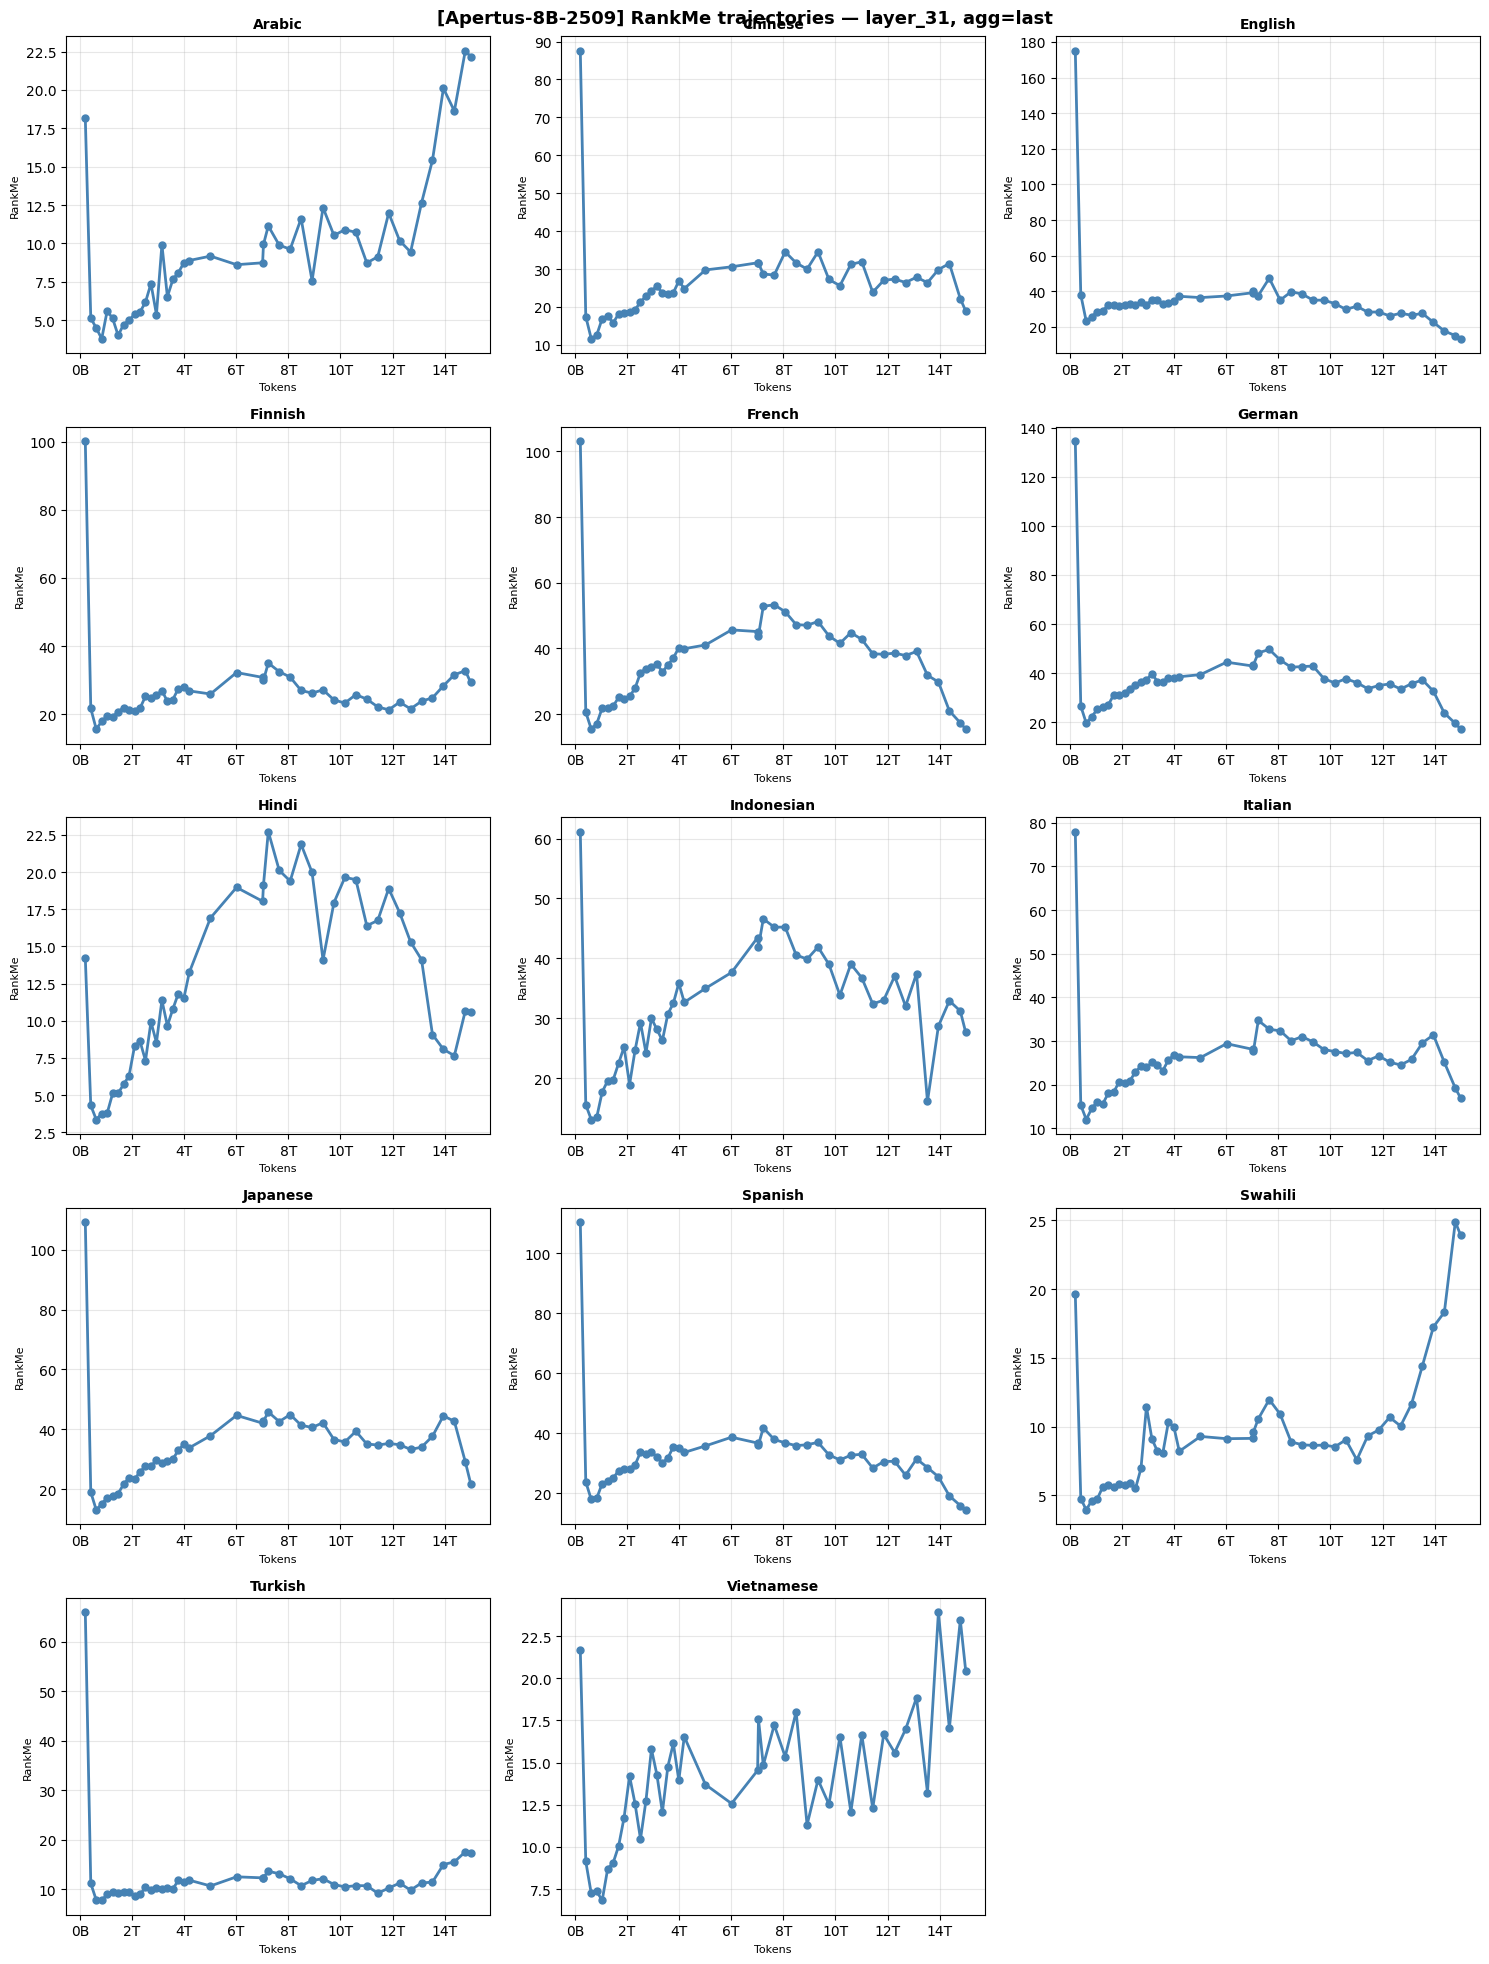

Saved: plots/rankme_phases_apertus.png


In [5]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    plot_rankme_phases(d["df_layer"], d["checkpoints_all"], d["token_counts"],
                       d["langs_sorted"], cfg["model_label"], cfg["layer"], cfg["aggregation"],
                       cfg["plots_dir"], model_key=m)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task:

- **grokking_tokens (B)** — token count (in billions) at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [6]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        df_grokking = compute_grokking(d["df_eval"], cfg["task_languages"], cfg["random_chance"],
                                       threshold=cfg["grokking_threshold"],
                                       min_consecutive=cfg["grokking_min_consec"])
        d["df_grokking"] = df_grokking
        display_cols = {
            "task":            "task",
            "language":        "language",
            "grokking_tokens": "grokking onset (B)",
            "peak_tokens":     "peak (B)",
            "peak_accuracy":   "peak accuracy",
            "random_chance":   "random chance",
        }
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_grokking[list(display_cols)].rename(columns=display_cols).to_string(index=False))
    else:
        d["df_grokking"] = pd.DataFrame()
        print(f"[{m}] No eval data — run submit_eval.sh + merge_results.py first.")


── FuxiTranyu-8B ────────────────────────────────────────
  task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
m_mmlu    English                 NaN     115.0       0.272590           0.25
m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
m_mmlu     German                 NaN     199.0       0.274928           0.25
m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
m_mmlu    Italian                 NaN     415.0       0.275818           0.25
m_mmlu     Arabic                 NaN     531.0       0.273824           0.25
m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
 xcopa    Chinese               325.0     426.0       0.664000           0.50
 xcopa    Italian               241.0     520.0       0.718000           0.50
 xcopa Vietnamese               126.0     436.0       0.736000           0.50
 xcop

## Overlay Plots

One plot per task (m-MMLU, XCOPA), with one panel per language. Each panel shows two y-axes:

- **Left axis (blue)** — RankMe trajectory across all checkpoints.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — absent when grokking was not detected.

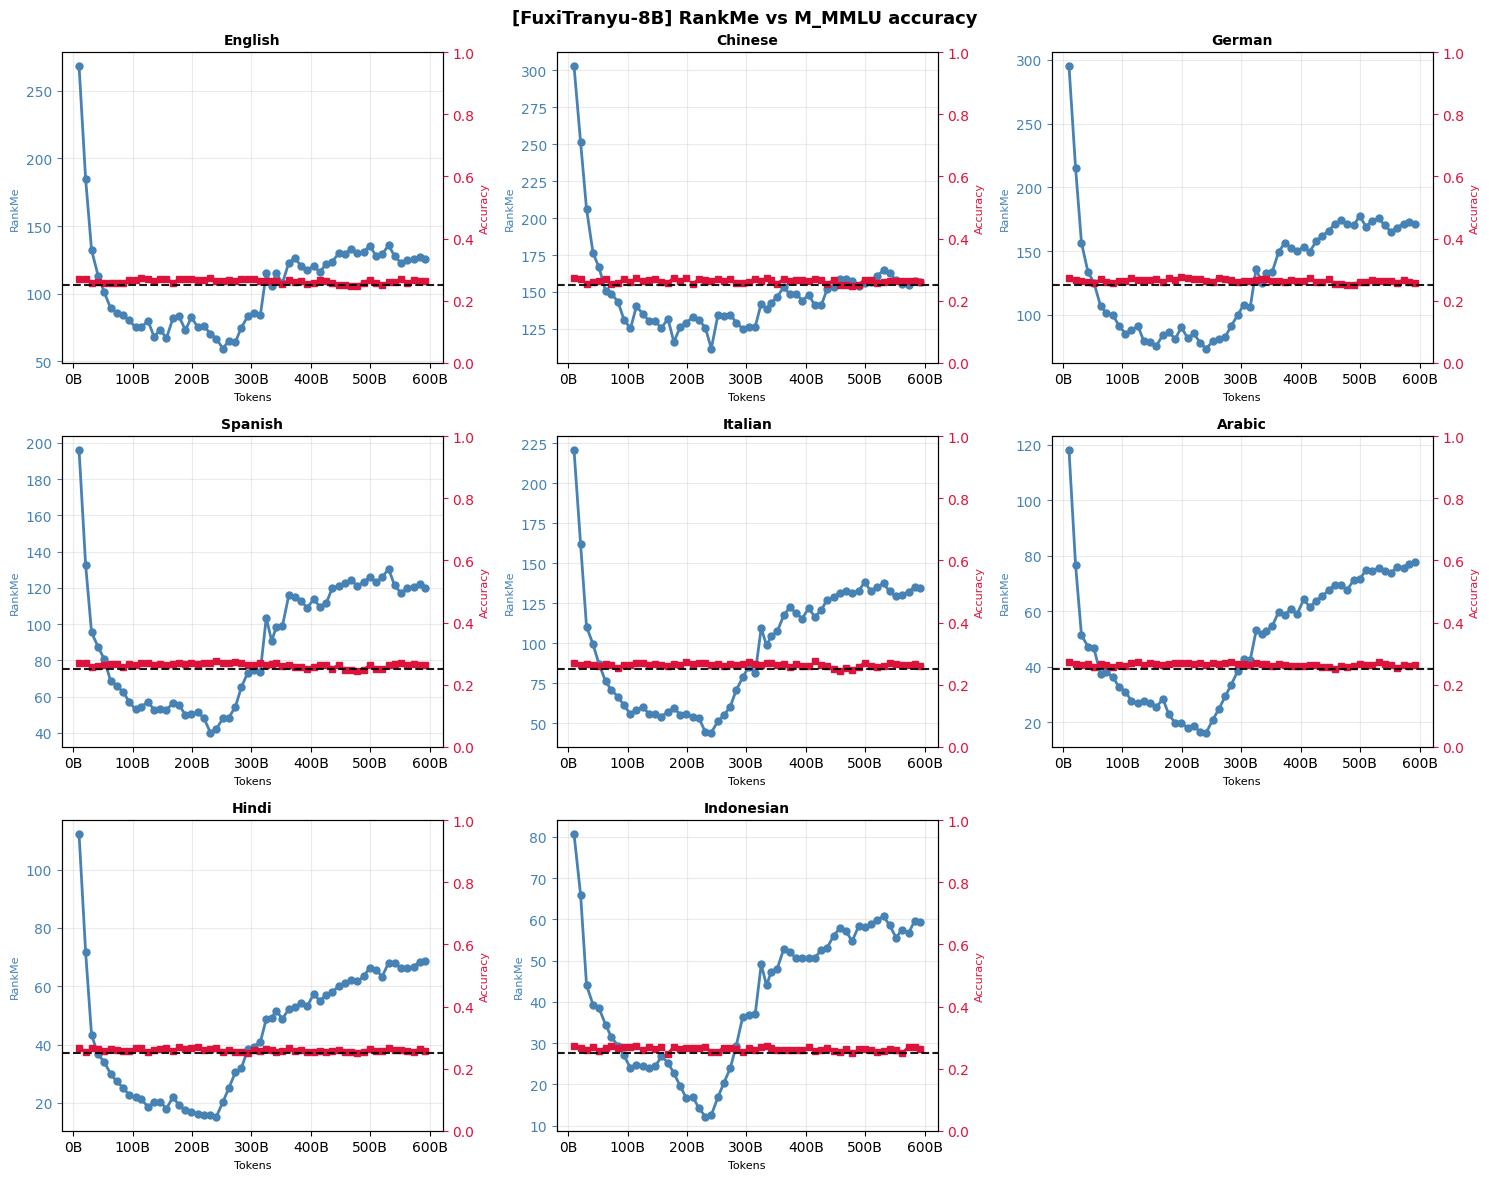

Saved: plots/overlay_m_mmlu_fuxi.png


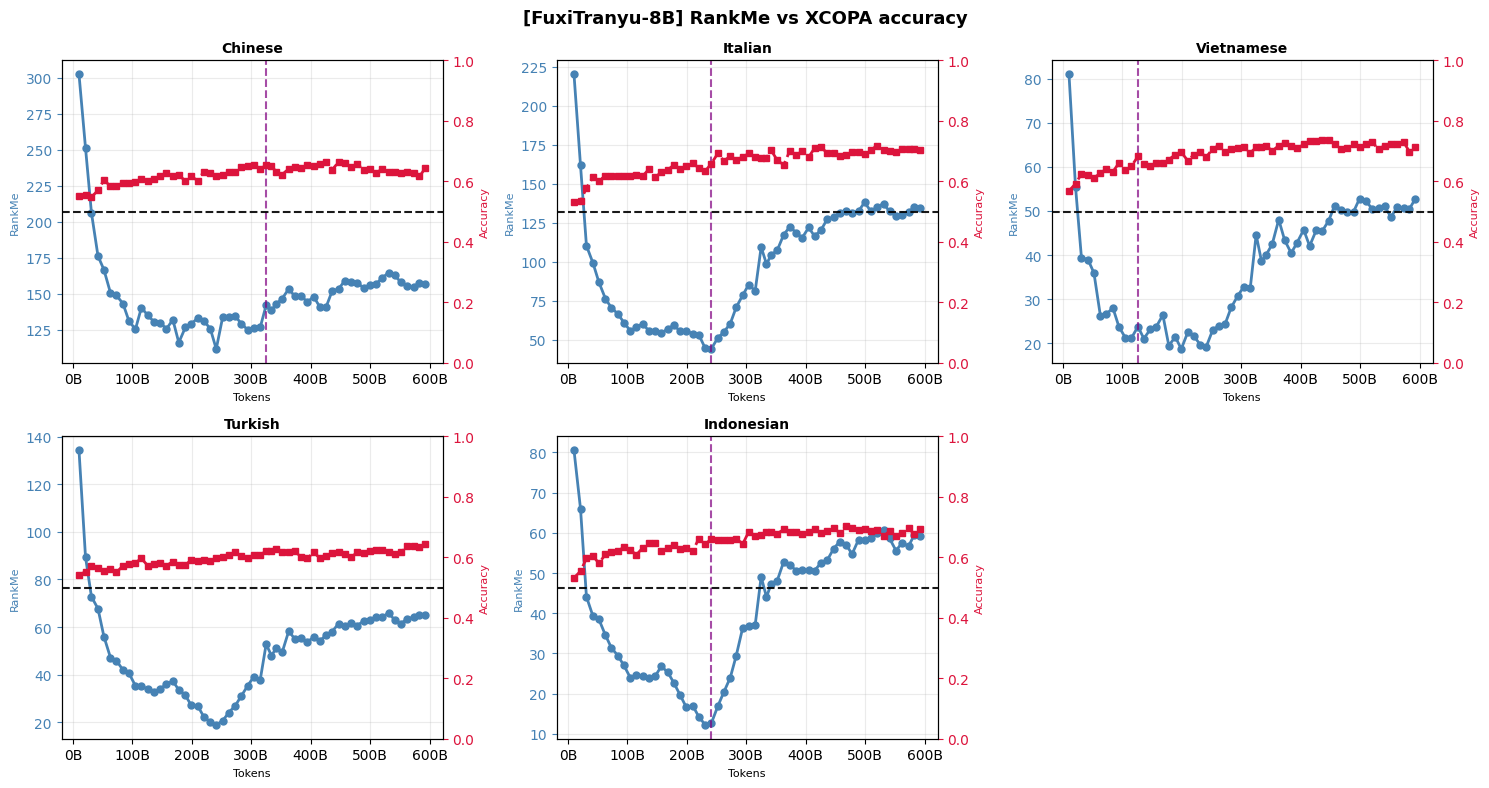

Saved: plots/overlay_xcopa_fuxi.png


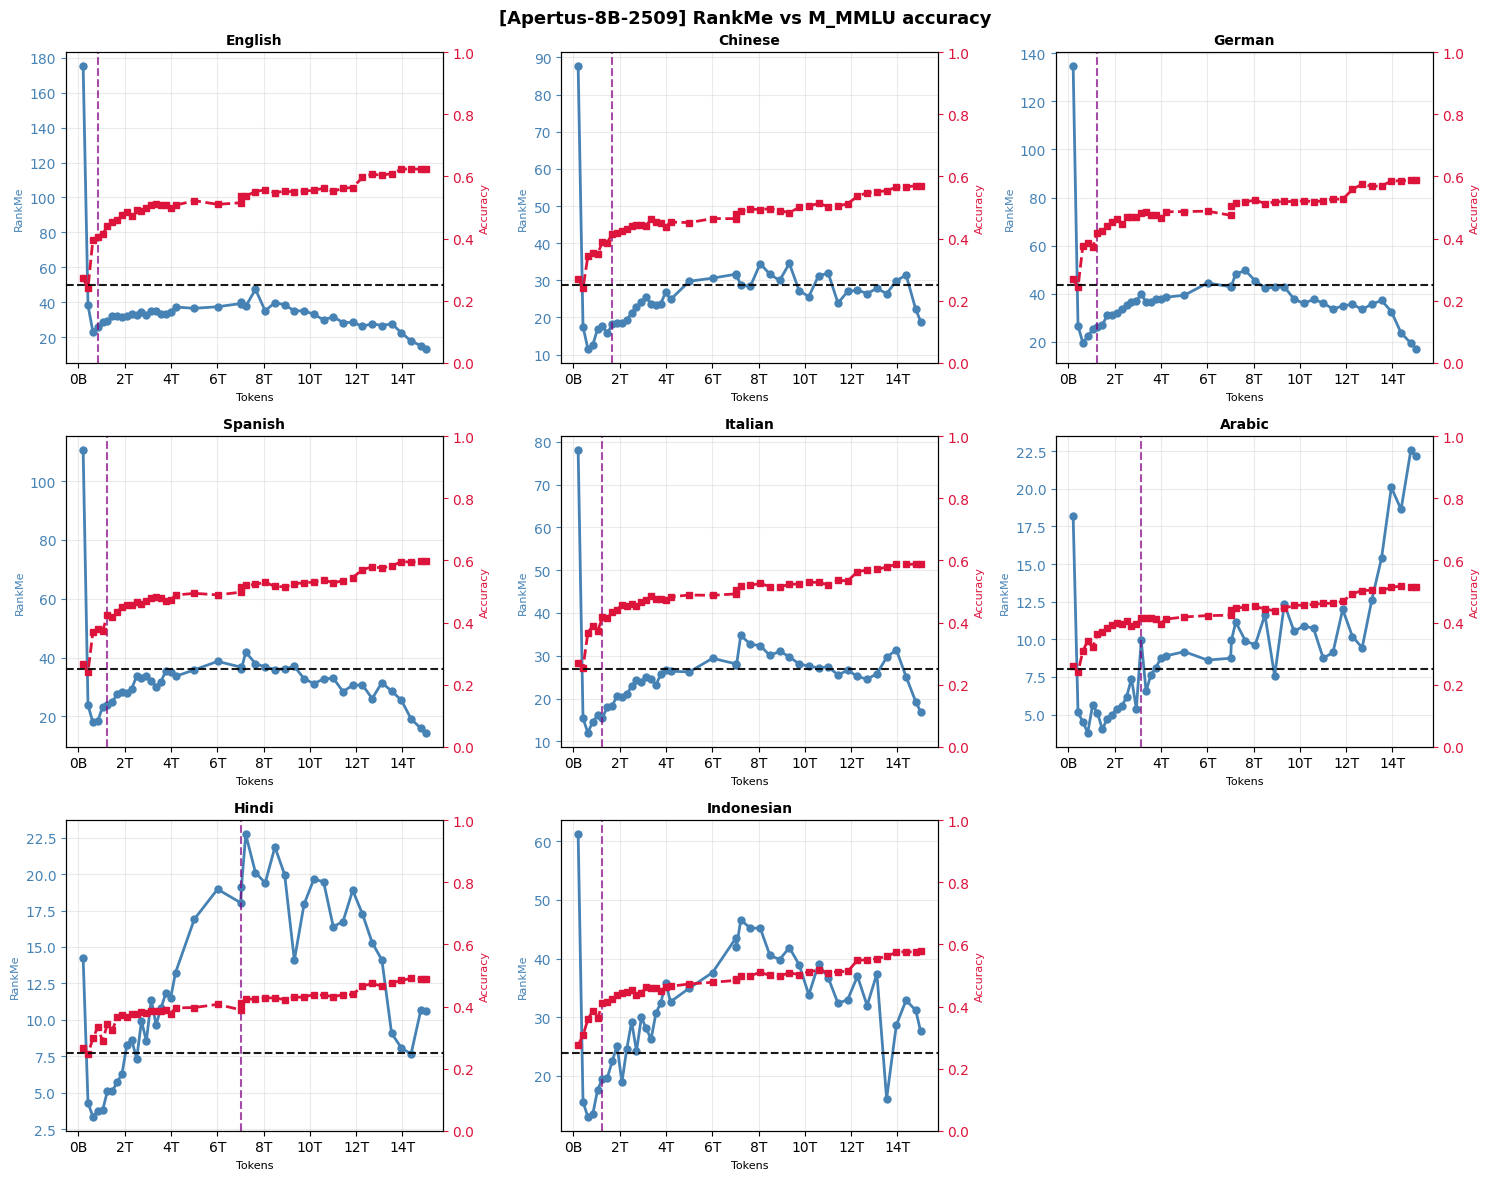

Saved: plots/overlay_m_mmlu_apertus.png


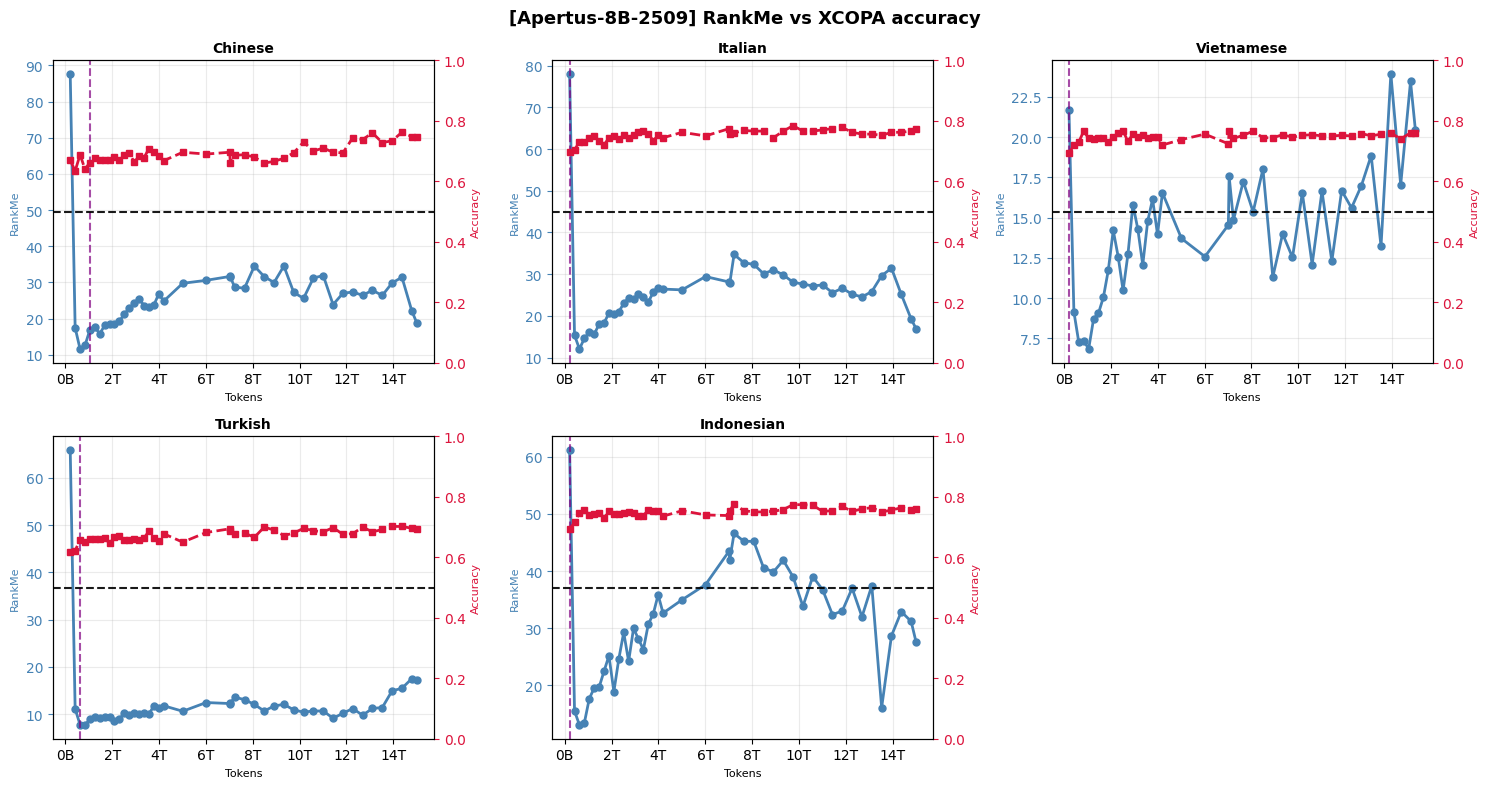

Saved: plots/overlay_xcopa_apertus.png


In [7]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        plot_overlay(d["df_eval"], d["df_layer"], d["df_grokking"],
                     cfg["task_languages"], cfg["random_chance"],
                     d["checkpoints_all"], d["token_counts"], d["langs_sorted"],
                     cfg["model_label"], cfg["plots_dir"], model_key=m)
    else:
        print(f"[{m}] Skipping overlay plots — run evaluate.py first.")

## Correlation Analysis

Tests whether RankMe geometry predicts downstream performance. Four predictors are tested against two outcomes, separately per task:

- **RankMe at first ckpt** — representation richness at the start of training; the strongest single predictor for Apertus.
- **Valley of first descent (B)** — token count at the bottom of the initial compression drop; has genuine variance across languages even when compression onset is constant.
- **Initial RankMe drop rate (1/B)** — (RankMe[first] − RankMe[valley]) / (tokens[valley] − tokens[first]); how steeply the model compresses each language's representations during the initial descent.
- **RankMe at last ckpt** — representation richness at the end of training.

Outcomes:
- **Grokking onset (B)** — when accuracy first crosses the threshold.
- **Peak accuracy** — highest accuracy across all checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [8]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"] and not d["df_grokking"].empty:
        df_correlations = compute_correlations_table(d["df_grokking"], d["df_geometry"])
        d["df_correlations"] = df_correlations
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_correlations.to_string(index=False))
    else:
        d["df_correlations"] = pd.DataFrame()
        print(f"[{m}] Skipping correlation analysis — no eval data available.")


── FuxiTranyu-8B ────────────────────────────────────────
  task                  predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu           RankMe at first ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu           RankMe at first ckpt      Peak accuracy            8      0.0952      0.8225     0.3315     0.4225
m_mmlu    Valley of first descent (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu    Valley of first descent (B)      Peak accuracy            8     -0.3780      0.3559    -0.5611     0.1479
m_mmlu Initial RankMe drop rate (1/B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu Initial RankMe drop rate (1/B)      Peak accuracy            8      0.0476      0.9108     0.4139     0.3080
m_mmlu            RankMe at last ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu       

One 2×2 figure per predictor (rows = M-MMLU / XCOPA, columns = grokking onset / peak accuracy). Both models are overlaid in each panel with a per-model regression line and Spearman/Pearson statistics in the title.

In [9]:
models_data = [
    {
        "label":       data[m]["cfg"]["model_label"],
        "df_grokking": data[m].get("df_grokking", pd.DataFrame()),
        "df_geometry": data[m].get("df_geometry", pd.DataFrame()),
        "color":       data[m]["color"],
        "marker":      data[m]["marker"],
    }
    for m in MODELS if data[m]["eval_available"]
]

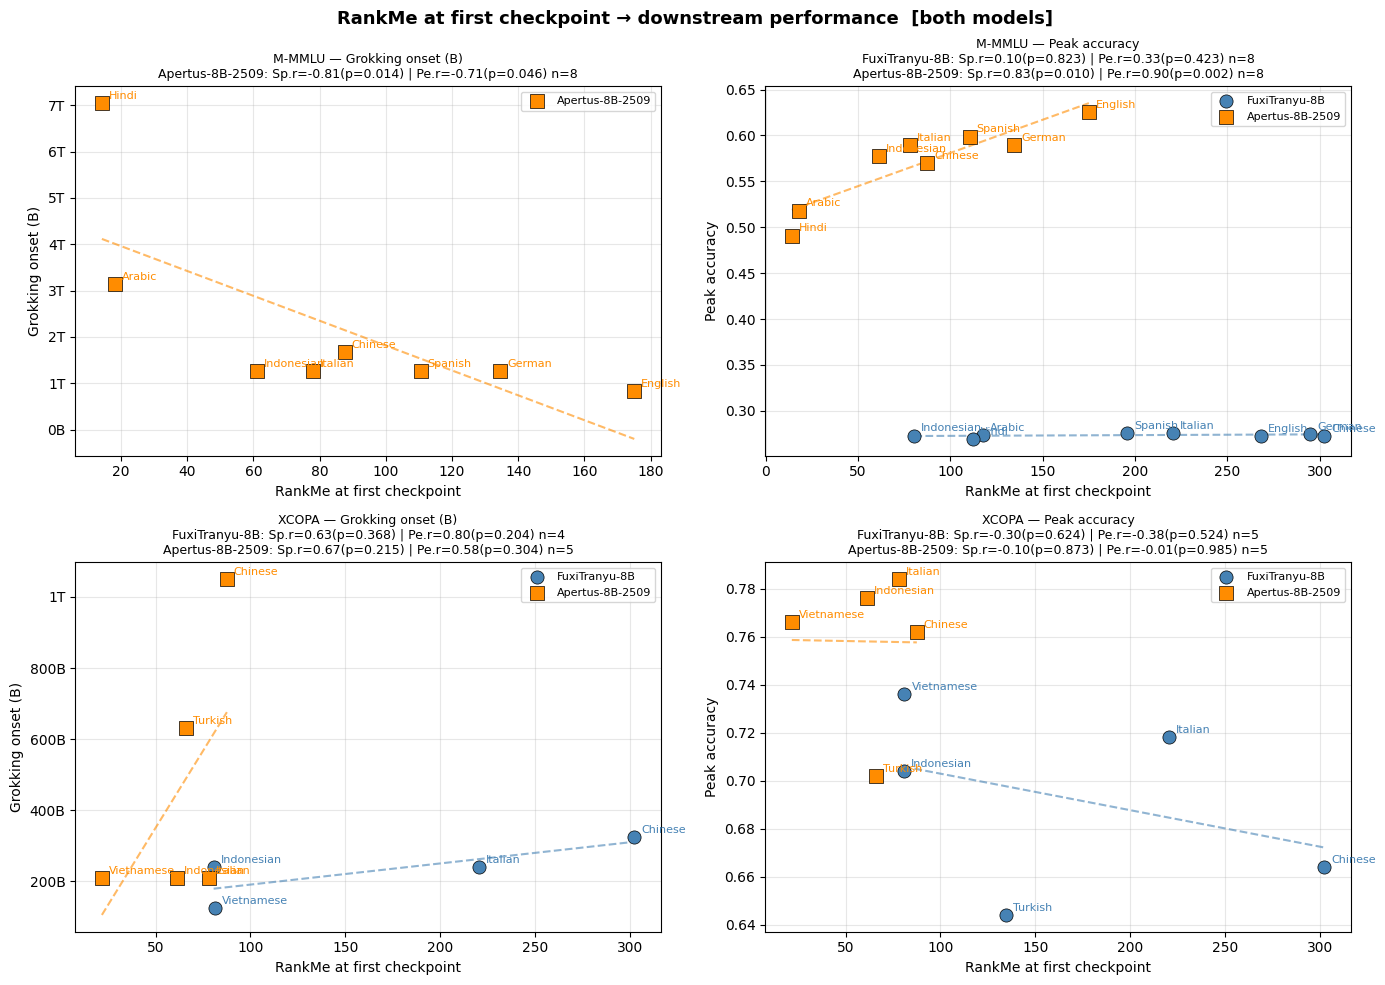

Saved: plots/scatter_rankme_first.png


In [10]:
if models_data:
    plot_predictor_scatter(models_data, "rankme_first",
                           "RankMe at first checkpoint", data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping scatter — no eval data available.")

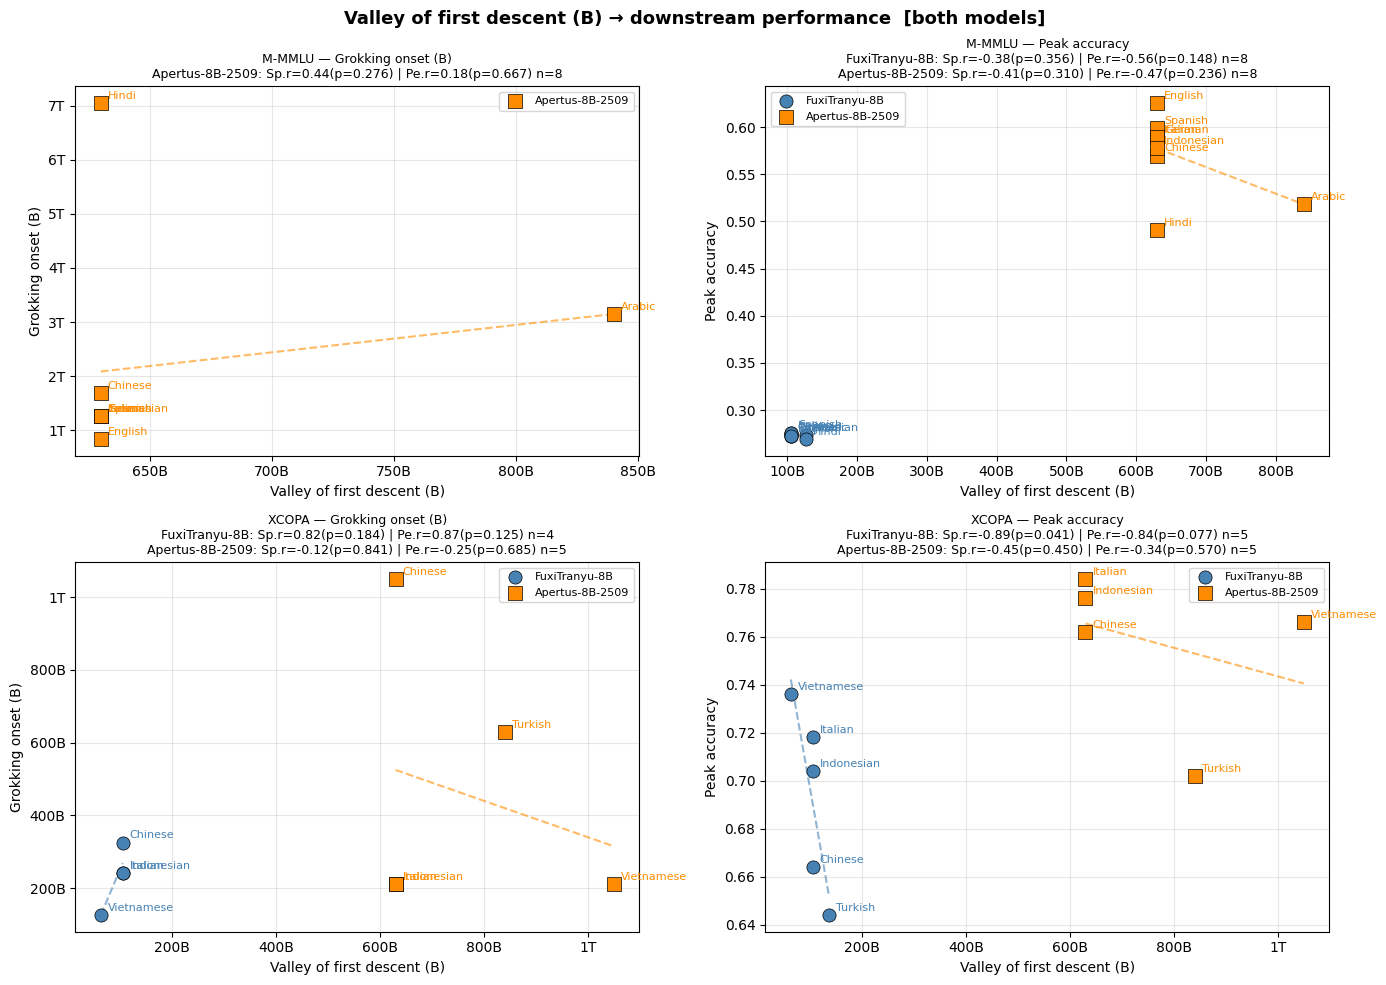

Saved: plots/scatter_valley_tokens.png


In [11]:
if models_data:
    plot_predictor_scatter(models_data, "valley_tokens",
                           "Valley of first descent (B)", data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping scatter — no eval data available.")

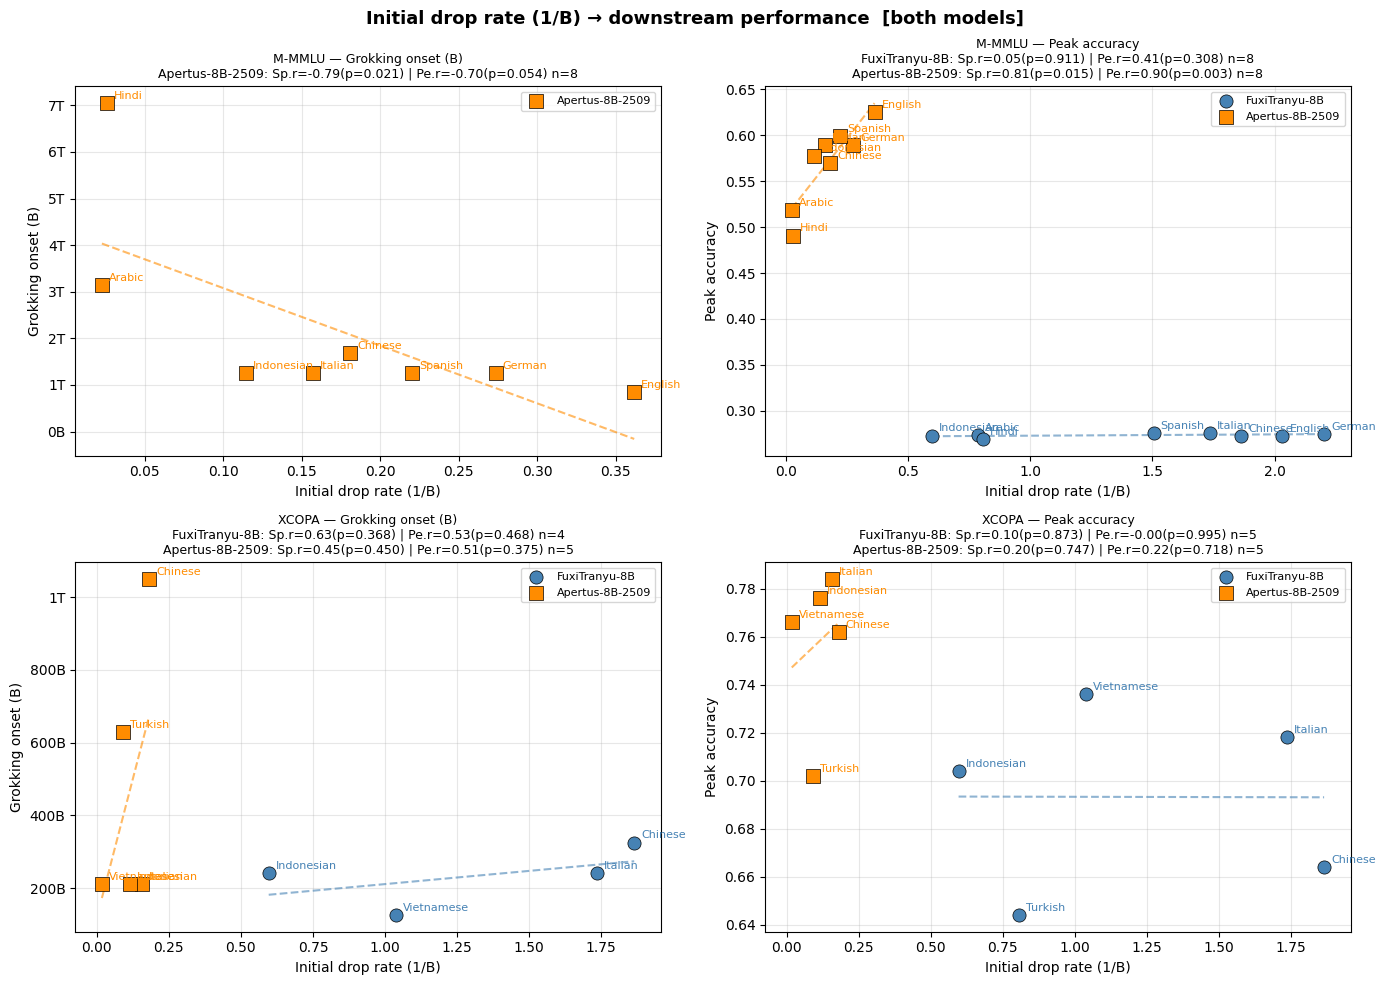

Saved: plots/scatter_rankme_initial_drop_rate.png


In [12]:
if models_data:
    plot_predictor_scatter(models_data, "rankme_initial_drop_rate",
                           "Initial drop rate (1/B)", data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping scatter — no eval data available.")

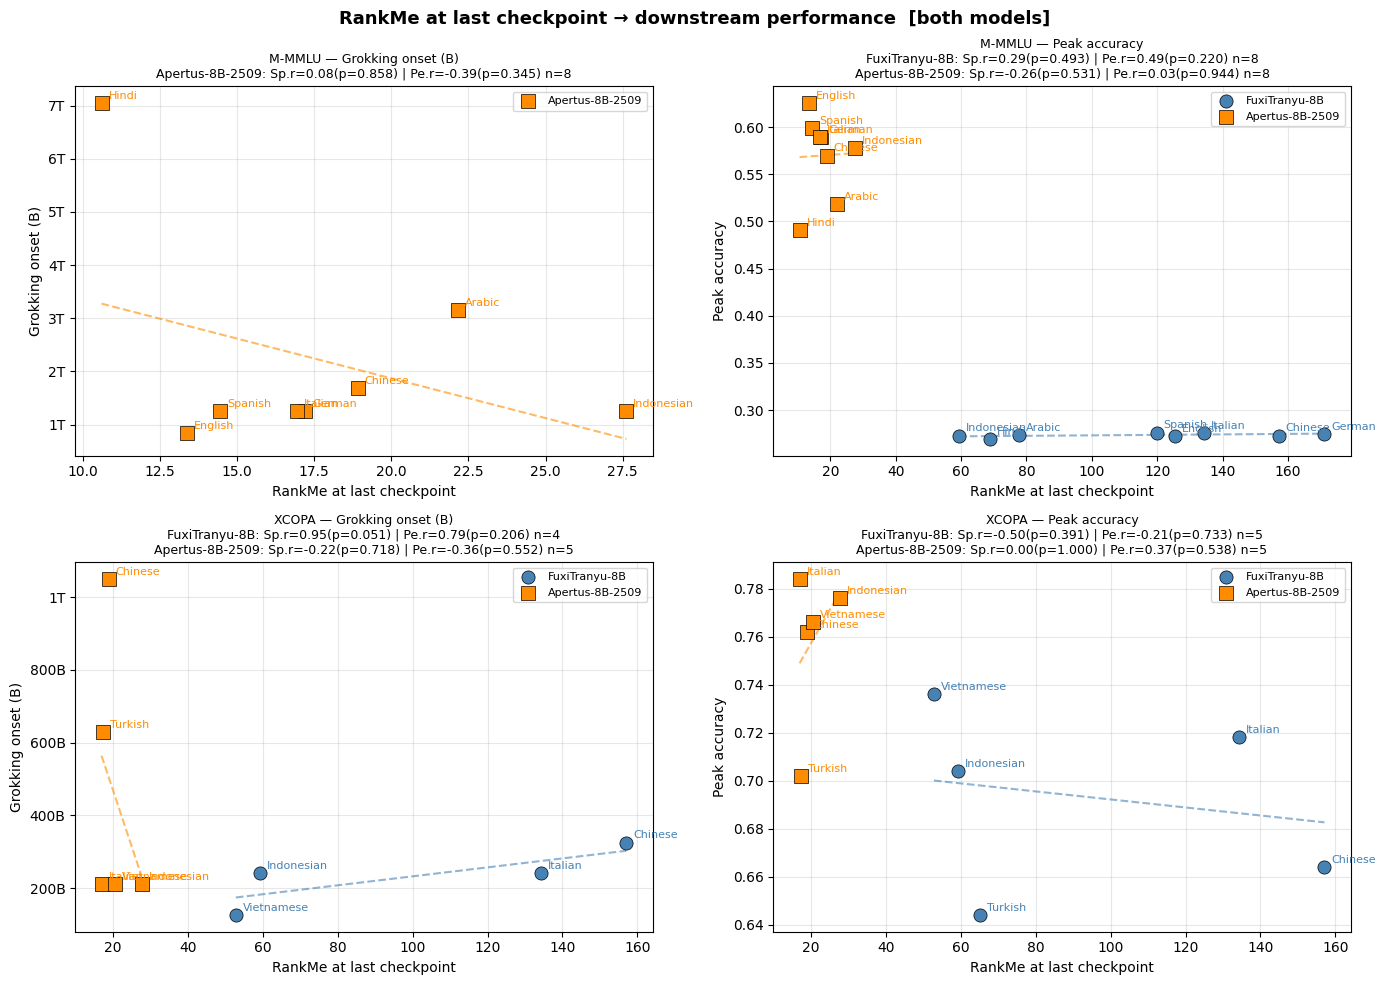

Saved: plots/scatter_rankme_last.png


In [13]:
if models_data:
    plot_predictor_scatter(models_data, "rankme_last",
                           "RankMe at last checkpoint", data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping scatter — no eval data available.")

## RankMe Findings

### FuxiTranyu-8B

**Phase structure (RankMe, all 14 languages)**

- RankMe peaks at the very first checkpoint (10B tokens) for every language — the entropy-seeking phase, if it existed, happened before our earliest observation. Compression-seeking begins immediately and lasts the full 593B tokens of training.
- RankMe magnitude varies substantially across languages both at the start (Arabic/Hindi/Swahili/Indonesian ~56–118; Japanese/Chinese/German ~295–374) and at the end (Swahili 38; Japanese 182).
- Higher-resource languages maintain higher absolute RankMe values throughout training; low-resource languages start and end lower, but their proportional compression rates are comparable.

**m-MMLU knowledge accuracy (8 languages)**

- Accuracy remains at random chance (~25%) for all 8 languages across all 57 checkpoints — no language exceeds the grokking threshold. No grokking is detected.
- The spread in peak accuracy is negligible (0.269–0.276, < 1 pp), within noise. No RankMe predictor shows a significant correlation with m-MMLU performance (all |Sp r| < 0.38, all p > 0.35).
- Factual knowledge retrieval (m-MMLU) does not emerge during pre-training for this model, regardless of language or representation geometry.

**XCOPA commonsense accuracy (5 languages)**

- All 5 languages exceed the 50% baseline from the earliest checkpoints, indicating commonsense reasoning emerges very early in training.
- Grokking is detected in 4 of 5 languages: Vietnamese first (126B), Italian and Indonesian simultaneously (241B), Chinese (325B). Turkish never reaches the 15 pp threshold above random chance (peak accuracy 0.644, threshold 0.65).
- Performance ranking: Vietnamese (0.736) > Italian (0.718) > Indonesian (0.704) > Chinese (0.664) > Turkish (0.644). Latin-script languages outperform, consistent with cross-lingual transfer from English.
- **Valley of first descent predicts XCOPA peak accuracy: Spearman r=−0.894, p=0.041 (n=5).** Languages where the initial compression bottoms out earlier achieve higher peak XCOPA accuracy. This is the only significant correlation for Fuxi and suggests the *speed* of the initial compression phase (reaching its minimum quickly) is associated with better commonsense performance.
- RankMe at the last checkpoint shows a marginal positive trend with grokking onset (Sp r=+0.95, p=0.051, n=4) — higher final RankMe associates with *later* grokking, a counterintuitive direction that does not reach significance. All remaining predictors show no relationship with XCOPA outcomes (all p > 0.18).

---

### Apertus-8B-2509

**Phase structure (RankMe, all 14 languages)**

- Two qualitatively different patterns emerge across languages:
  - **10 languages** (Chinese, English, Finnish, French, German, Indonesian, Italian, Japanese, Spanish, Turkish) peak at the first observed checkpoint (210B) — only the compression-seeking phase is visible.
  - **4 languages** (Arabic, Swahili, Vietnamese, Hindi) show different patterns. Arabic and Swahili peak at ~14800B, Vietnamese at ~13950B, Hindi at ~7230B — near the end of training.
- RankMe at the first checkpoint varies dramatically: English/German/Japanese (109–175) vs Arabic/Swahili/Hindi (14–20).

**m-MMLU knowledge accuracy (8 languages) — strong findings**

- Unlike Fuxi, Apertus grokked on m-MMLU in every evaluated language. Grokking onset spans 840B (English) to 7047B (Hindi). Peak accuracy spans 0.491 (Hindi) to 0.625 (English).
- **The initial representational richness (RankMe at first checkpoint) is the strongest single predictor of both outcomes:**
  - → Peak m-MMLU accuracy: **Spearman r=+0.833, p=0.010; Pearson r=+0.904, p=0.002** (n=8). Languages whose representations are richer at 210B tokens achieve significantly higher factual accuracy at the end of training.
  - → Grokking onset: **Spearman r=−0.812, p=0.014** (n=8). Languages with richer initial representations grok earlier.
- **The initial RankMe drop rate is an equally strong predictor:**
  - → Peak accuracy: **Spearman r=+0.810, p=0.015; Pearson r=+0.896, p=0.003** (n=8). Languages that compress faster in the initial descent also achieve higher factual accuracy.
  - → Grokking onset: **Spearman r=−0.786, p=0.021** (n=8). Faster initial drop → earlier grokking.
- RankMe at the *last* checkpoint and the valley of the first descent show no significant correlation with either outcome (all p > 0.23) — it is the *starting* richness and the *rate of initial compression*, not the timing of the valley or the final richness, that matter for Apertus.
- **Interpretation:** Initial representational richness at 210B tokens acts as a proxy for how much multilingual pre-training signal a language has absorbed by that point. Languages with richer early representations (high-resource, Latin/CJK-script) both achieve higher factual accuracy and transition to knowledge retrieval earlier.

**XCOPA commonsense accuracy (5 languages)**

- All 5 languages grok in Apertus (vs 4 in Fuxi, where Turkish never reached threshold). Italian and Indonesian grok earlier (210B vs 241B); Turkish grokked only in Apertus (630B); but Vietnamese (210B vs 126B) and Chinese (1050B vs 325B) grok later in Apertus than in Fuxi.
- Peak accuracy is uniformly high: Italian (0.784), Vietnamese (0.766), Indonesian (0.776), Chinese (0.762), Turkish (0.702) — all substantially above Fuxi's range (0.644–0.736).
- No significant RankMe correlation with XCOPA outcomes (all p > 0.20).


### Workflow
```bash
# 1 — Submit one cluster job per checkpoint (see README)
for ckpt in 10B 115B ...; do
    ./downstream_evaluation/submit_eval.sh $ckpt fuxi
done

# 2 — After all jobs complete, merge once manually (see README)

# 3 — Rerun this notebook — all cells activate automatically
```